In [42]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import random

In [43]:
random.seed(42)
np.random.seed(111)

In [44]:
def compute_disparity(sensitive_attributes, targets, possible_sensitive_attributes, possible_targets):
    disparities = []
    # Compute the disparity
    for target in possible_targets:
        for sensitive_attribute in possible_sensitive_attributes:
            Z_equal_z = len(sensitive_attributes[sensitive_attributes == sensitive_attribute])
            Z_not_equal_z = len(sensitive_attributes) - Z_equal_z

            Z_equal_z_and_Y_equal_target = len(
                sensitive_attributes[(sensitive_attributes == sensitive_attribute) & (targets == target)]
            )
            Z_not_equal_z_and_Y_equal_target = len(
                sensitive_attributes[(sensitive_attributes != sensitive_attribute) & (targets == target)]
            )
            disparities.append(
                abs(Z_equal_z_and_Y_equal_target / Z_equal_z - Z_not_equal_z_and_Y_equal_target / Z_not_equal_z)
            )
    print(max(disparities))
    return disparities

In [45]:
ca = pd.read_csv("./Income_acs/CA.csv")
ny = pd.read_csv("./Income_acs/NY.csv")
al = pd.read_csv("./Income_acs/AL.csv")
tx = pd.read_csv("./Income_acs/TX.csv")

In [ ]:
ca.head()

In [47]:
# # convert the column <20min to 0 and 1
# ca["<20min"] = ca["<20min"].apply(lambda x: 1 if x == True else 0)
# ny["<20min"] = ny["<20min"].apply(lambda x: 1 if x == True else 0)

In [48]:
# sensitive_value = "Gender"
# target = ">50K"
# ca_sensitive = np.array(ca[sensitive_value])
# ny_sensitive = np.array(ny[sensitive_value])
# al_sensitive = np.array(al[sensitive_value])

# ca_target = np.array(ca[target])
# ny_target = np.array(ny[target])
# al_target = np.array(al[target])

In [49]:
# ca = filter_df(Counter(ca_race), ca)
# ny = filter_df(Counter(ny_race), ny)
# mi = filter_df(Counter(mi_race), mi)
# tx = filter_df(Counter(tx_race), tx)

In [50]:
# ca_race_and_target = Counter(
#     [(target, race) for target, race in zip(ca_target, ca_sensitive)]
# )
# ny_race_and_target = Counter(
#     [(target, race) for target, race in zip(ny_target, ny_sensitive)]
# )
# al_race_and_target = Counter(
#     [(target, race) for target, race in zip(al_target, al_sensitive)]
# )
# # mi_race_and_target = Counter(
# #     [(target, race) for target, race in zip(mi_target, mi_race)]
# # )
# # tx_race_and_target = Counter(
# #     [(target, race) for target, race in zip(tx_target, tx_race)]
# # )

In [51]:
# plot the distribution of ca_race_and_target
def plot(race_and_target):
    # Get the keys and values from the Counter
    keys = list([str(key) for key in race_and_target.keys()])
    values = list(race_and_target.values())
    # sort the keys and values
    keys, values = zip(*sorted(zip(keys, values)))

    # Plot the distribution
    plt.bar(keys, values)
    plt.xlabel("Race and Target")
    plt.ylabel("Count")
    plt.title("Distribution of Race and Target")
    plt.xticks(rotation=90)
    plt.show()

# Compute the disparities

In [52]:
# compute_disparity(
#     np.array(ca_sensitive),
#     np.array(ca_target),
#     np.unique(ca_sensitive),
#     np.unique(ca_target),
# )

In [53]:
# compute_disparity(
#     np.array(ny_sensitive),
#     np.array(ny_target),
#     np.unique(ny_sensitive),
#     np.unique(ny_target),
# )

In [54]:
# compute_disparity(
#     np.array(al_sensitive),
#     np.array(al_target),
#     np.unique(al_sensitive),
#     np.unique(al_target),
# )

# Merge the dataset

In [55]:
def pre_process_income(df, state_name):
    """
    Pre-process the income dataset to make it ready for the simulation
    In this function we consider "SEX" as the sensitive value and "PINCP" as the target value.

    Args:
        data: the raw data
        years_list: the list of years to be considered
        states_list: the list of states to be considered

    Returns:
        Returns a list of pre-processed data for each state, if multiple years are
        selected, the data are concatenated.
        We return three lists:
        - The first list contains a pandas dataframe of features for each state
        - The second list contains a pandas dataframe of labels for each state
        - The third list contains a pandas dataframe of groups for each state
        The values in the list are numpy array of the dataframes
    """

    categorical_columns = ["COW", "SCHL", "MAR", "RAC1P"]
    continuous_columns = ["AGEP", "WKHP", "OCCP", "POBP", "RELP"]
    dataframes = []
    labels = []
    groups = []
    dataframe = pd.DataFrame()
    label = pd.DataFrame()
    group = pd.DataFrame()

    # get the target and sensitive attributes
    target_attributes = df[">50K"]
    sensitive_attributes = df["Gender"]

    # convert the columns to one-hot encoding
    df = pd.get_dummies(df, columns=categorical_columns)

    # normalize the continuous columns between 0 and 1
    for col in continuous_columns:
        df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

    # convert label to int
    target_attributes = target_attributes.astype(int)

    # remove the columns that have state different than "state name"
    df = df[df["state"] == state_name]
    target_attributes = df[">50K"]
    sensitive_attributes = df["Gender"]
    sensitive_attributes = [1 if item == 1 else 0 for item in sensitive_attributes]
    df = df.drop([">50K", "Gender", "state"], axis=1)

    # target_attributes = target_attributes[state == state_name]
    # tmp = []
    # state = list(state)
    # print(sensitive_attributes)
    # for index, item in enumerate(sensitive_attributes):
    #     if state[index] == state_name:
    #         tmp.append(item)

    # concatenate the dataframes
    dataframe = pd.concat([dataframe, df])
    # convert the labels and groups to dataframes
    label = pd.concat([label, pd.DataFrame(target_attributes)])
    group = pd.concat([group, pd.DataFrame(sensitive_attributes)])
    assert len(dataframe) == len(label) == len(group)
    dataframes.append(dataframe.to_numpy())
    labels.append(label.to_numpy())
    groups.append(group.to_numpy())
    return dataframes, labels, groups

In [56]:
# # remove unnamed column
# merged = merged.loc[:, ~merged.columns.str.contains("^Unnamed")]
features = [
    "AGEP",
    "COW",
    "SCHL",
    "MAR",
    "OCCP",
    "POBP",
    "RELP",
    "WKHP",
    "SEX",
    "RAC1P",
    "Gender",
    ">50K",
    "state",
]
# merged.columns = features

ca = ca.loc[:, ~ca.columns.str.contains("^Unnamed")]
ny = ny.loc[:, ~ny.columns.str.contains("^Unnamed")]
al = al.loc[:, ~al.columns.str.contains("^Unnamed")]
tx = tx.loc[:, ~tx.columns.str.contains("^Unnamed")]

ca.columns = features
ny.columns = features
al.columns = features
tx.columns = features

In [57]:
# merged.head()

In [58]:
# gender = merged["Gender"]
# target = merged[">50K"]

# # remove Gender and >50K columns
# merged = merged.drop(["Gender", ">50K"], axis=1)
# merged.head()

In [59]:
# # test the preprocessing
# dataframes, labels, groups = pre_process_income(merged.drop(["state"], axis=1))

In [60]:
def representative_diversity_approach(X, y, z, num_nodes, number_of_samples_per_node):
    """
    With this approach we want to distribute the data among the nodes in a representative diversity way.
    This means that each node has the same ratio of each group that we are observing in the dataset

    params:
    X: numpy array of shape (N, D) where N is the number of samples and D is the number of features
    y: numpy array of shape (N, ) where N is the number of samples. Here we have the samples labels
    z: numpy array of shape (N, ) where N is the number of samples. Here we have the samples sensitive features
    num_nodes: number of nodes to generate
    number_of_samples_per_node: number of samples that we want in each node. Can be None, in this case we just use
        len(y)//num_nodes
    """
    samples_per_node = number_of_samples_per_node if number_of_samples_per_node else len(y) // num_nodes
    # create the nodes sampling from the dataset wihout replacement
    dataset = [{"x": x_, "y": y_, "z": z_} for x_, y_, z_ in zip(X, y, z)]
    # shuffle the dataset
    np.random.shuffle(dataset)

    # Distribute the data among the nodes with a random sample from the dataset
    # considering the number of samples per node
    nodes = []
    for i in range(num_nodes):
        nodes.append([])
        nodes[i].extend(dataset[:samples_per_node])
        dataset = dataset[samples_per_node:]

    # Create the dictionary with the remaining data
    remaining_data = {}
    for sample in dataset:
        if (sample["y"], sample["z"]) not in remaining_data:
            remaining_data[(sample["y"], sample["z"])] = []
        remaining_data[(sample["y"], sample["z"])].append(sample)

    return nodes, remaining_data


def create_unfair_nodes(
    fair_nodes: list,
    nodes_to_unfair: list,
    remaining_data: dict,
    group_to_reduce: tuple,
    group_to_increment: tuple,
    ratio_unfairness: tuple,
):
    """
    This function creates the unfair nodes. It takes the nodes that we want to be unfair and the remaining data
    and it returns the unfair nodes created by reducing the group_to_reduce and incrementing the group_to_increment
    based on the ratio_unfairness

    params:
    nodes_to_unfair: list of nodes that we want to make unfair
    remaining_data: dictionary with the remaining data that we will use to replace the
        samples that we remove from the nodes_to_unfair
    group_to_reduce: the group that we want to be unfair. For instance, in the case of binary target and binary sensitive value
        we could have (0,0), (0,1), (1,0) or (1,1)
    group_to_increment: the group that we want to increment. For instance, in the case of binary target and binary sensitive value
        we could have (0,0), (0,1), (1,0) or (1,1)
    ratio_unfairness: tuple (min, max) where min is the minimum ratio of samples that we want to remove from the group_to_reduce
    """
    # assert (
    #     remaining_data[group_to_reduce] != []
    # ), "Choose a different group to be unfair"
    # remove the samples from the group that we want to be unfair
    unfair_nodes = []
    number_of_samples_to_add = []
    removed_samples = []

    for node in nodes_to_unfair:
        node_data = []
        count_sensitive_group_samples = 0
        # We count how many sample each node has from the group that we want to reduce
        for sample in node:
            if (sample["y"], sample["z"]) == group_to_reduce:
                count_sensitive_group_samples += 1

        # We compute the number of samples that we want to remove from the group_to_reduce
        # based on the ratio_unfairness
        current_ratio = np.random.uniform(ratio_unfairness[0], ratio_unfairness[1])
        samples_to_be_removed = int(count_sensitive_group_samples * current_ratio)
        number_of_samples_to_add.append(samples_to_be_removed)

        for sample in node:
            # Now we remove the samples from the group_to_reduce
            # and we store them in removed_samples
            if (
                sample["y"],
                sample["z"],
            ) == group_to_reduce and samples_to_be_removed > 0:
                samples_to_be_removed -= 1
                removed_samples.append(sample)
            else:
                node_data.append(sample)
        unfair_nodes.append(node_data)

    # Now we have to distribute the removed samples among the fair nodes
    max_samples_to_add = len(removed_samples) // len(fair_nodes)
    for node in fair_nodes:
        node.extend(removed_samples[:max_samples_to_add])
        removed_samples = removed_samples[max_samples_to_add:]

    if group_to_increment:
        # Now we have to remove the samples from the group_to_increment
        # from the fair_nodes based on the number_of_samples_to_add
        for node in fair_nodes:
            samples_to_remove = sum(number_of_samples_to_add) // len(fair_nodes)
            for index, sample in enumerate(node):
                if (
                    sample["y"],
                    sample["z"],
                ) == group_to_increment and samples_to_remove > 0:
                    if (sample["y"], sample["z"]) not in remaining_data:
                        remaining_data[group_to_increment] = []
                    remaining_data[group_to_increment].append(sample)
                    samples_to_remove -= 1
                    node.pop(index)
            # if sum(number_of_samples_to_add) > 0:
            #     assert samples_to_remove == 0, "Not enough samples to remove"

        if group_to_increment in remaining_data:
            print("Adding data")
            # assert sum(number_of_samples_to_add) <= len(
            #     remaining_data[group_to_increment]
            # ), "Too many samples to add"
            # now we have to add the same amount of data taken from group_to_unfair
            for node, samples_to_add in zip(unfair_nodes, number_of_samples_to_add):
                node.extend(remaining_data[group_to_increment][:samples_to_add])
                remaining_data[group_to_increment] = remaining_data[group_to_increment][samples_to_add:]

    print(
        "remaining data: ",
        len(remaining_data[(0, 1)]),
        len(remaining_data[(1, 1)]),
        len(remaining_data[(0, 0)]),
        len(remaining_data[(1, 0)]),
    )
    return fair_nodes, unfair_nodes


from sklearn.preprocessing import MinMaxScaler


## Use this function to retrieve X, X, y arrays for training ML models
def dataset_to_numpy(
    _df,
    _feature_cols: list,
    _metadata: dict,
    num_sensitive_features: int = 1,
    sensitive_features_last: bool = True,
):
    """Args:
    _df: pandas dataframe
    _feature_cols: list of feature column names
    _metadata: dictionary with metadata
    num_sensitive_features: number of sensitive features to use
    sensitive_features_last: if True, then sensitive features are encoded as last columns
    """

    # transform features to 1-hot
    print(_feature_cols)
    print(_df.columns)
    _X = _df[_feature_cols]
    # take sensitive features separately
    print(f"Using {_metadata['protected_atts'][:num_sensitive_features]} as sensitive feature(s).")
    if num_sensitive_features > len(_metadata["protected_atts"]):
        num_sensitive_features = len(_metadata["protected_atts"])
    _Z = _X[_metadata["protected_atts"][:num_sensitive_features]]
    _X = _X.drop(columns=_metadata["protected_atts"][:num_sensitive_features])

    # 1-hot encode and scale features
    if "dummy_cols" in _metadata.keys():
        dummy_cols = _metadata["dummy_cols"]
    else:
        dummy_cols = None
    _X2 = pd.get_dummies(_X, columns=dummy_cols, drop_first=False)
    esc = MinMaxScaler()
    _X = esc.fit_transform(_X2)

    # original
    # current implementation assumes each sensitive feature is binary
    for i, tmp in enumerate(_metadata["protected_atts"][:num_sensitive_features]):
        assert len(_Z[tmp].unique()) == 2, "Sensitive feature is not binary!"

    # 1-hot sensitive features, (optionally) swap ordering so privileged class feature == 1 is always last, preceded by the corresponding unprivileged feature
    _Z2 = pd.get_dummies(_Z, columns=_Z.columns, drop_first=False)
    # print(_Z2.head(), _Z2.shape)
    if sensitive_features_last:
        for i, tmp in enumerate(_Z.columns):
            assert _metadata["protected_att_values"][i] in _Z[tmp].unique(), (
                "Protected attribute value not found in data!"
            )
            if not np.allclose(float(_metadata["protected_att_values"][i]), 0):
                # swap columns
                _Z2.iloc[:, [2 * i, 2 * i + 1]] = _Z2.iloc[:, [2 * i + 1, 2 * i]]
    # change booleans to floats
    # _Z2 = _Z2.astype(float)

    # original
    _Z = _Z2.to_numpy()

    # _Z = _Z.to_numpy()

    _y = _df[_metadata["target_variable"]].values
    return _X, _Z, _y


def distribute_data(
    dataframes,
    labels,
    groups,
    num_nodes,
    number_of_samples_per_node,
    group_to_reduce=(0, 1),
    group_to_increment=(1, 1),
    ratio_unfairness=(0.7, 0.9),
):
    nodes, remaining_data = representative_diversity_approach(
        dataframes[0],
        np.array([item[0] for item in labels[0]]),
        np.array([item[0] for item in groups[0]]),
        num_nodes,
        number_of_samples_per_node,
    )

    fair_nodes, unfair_nodes = create_unfair_nodes(
        fair_nodes=nodes[:75],
        nodes_to_unfair=nodes[75:],
        remaining_data=remaining_data,
        group_to_reduce=group_to_reduce,
        group_to_increment=group_to_increment,
        ratio_unfairness=ratio_unfairness,
    )

    return fair_nodes + unfair_nodes


def distribute_data_with_egalitatian_approach(X, y, z, num_nodes, number_of_samples_per_node=None):
    """
    With this approach we want to distribute the data among the nodes in an egalitarian way.
    This means that each node has the same amount of data and the same ratio of each group

    params:
    X: numpy array of shape (N, D) where N is the number of samples and D is the number of features
    y: numpy array of shape (N, ) where N is the number of samples. Here we have the samples labels
    z: numpy array of shape (N, ) where N is the number of samples. Here we have the samples sensitive features
    num_nodes: number of nodes to generate
    number_of_samples_per_node: number of samples that we want in each node. Can be None, in this case we just use
        len(y)//num_nodes
    """
    combinations = [(target, sensitive_value) for target, sensitive_value in zip(y, z)]
    possible_combinations = set(combinations)
    data = {}
    for combination, x_, y_, z_ in zip(combinations, X, y, z):
        if combination not in data:
            data[combination] = []
        data[combination].append({"x": x_, "y": y_, "z": z_})

    samples_from_each_group = min(list(Counter(combinations).values())) // num_nodes

    if number_of_samples_per_node:
        assert samples_from_each_group * len(possible_combinations) >= number_of_samples_per_node, (
            "Too many samples per node, choose a different number of samples per node"
        )
        if samples_from_each_group * len(possible_combinations) >= number_of_samples_per_node:
            to_be_removed = (samples_from_each_group * len(possible_combinations) - number_of_samples_per_node) // len(
                possible_combinations
            )
            samples_from_each_group -= to_be_removed

    # create the nodes
    nodes = []
    for i in range(num_nodes):
        nodes.append([])
        # fill the nodes
        for combination in data:
            nodes[i].extend(data[combination][:samples_from_each_group])
            data[combination] = data[combination][samples_from_each_group:]

    return nodes, data


def convert_to_single(nodes_data):
    numpy_data = []
    for node in nodes_data:
        X = []
        Y = []
        Z = []

        for sample in node:
            X.append(sample["x"])
            Y.append(sample["y"])
            Z.append(sample["z"])

        X = np.array(X)
        Y = np.array(Y)
        Z = np.array(Z)
        numpy_data.append((X, Y, Z))
    return numpy_data

# Functions

In [61]:
def compute_distribution_debug(predictions, sensitive_features):
    counter_nodes = []
    for prediction, sensitive_feature in zip(predictions, sensitive_features):
        counter_node = []
        for pred, sf in zip(prediction, sensitive_feature):
            counter_node.append((pred, sf))
        counter_nodes.append(Counter(counter_node))
    return counter_nodes


def plot_distributions(title: str, counter_groups: list, nodes: list, all_combinations: list):
    plt.figure(figsize=(20, 8))
    previous_sum = []
    for combination in all_combinations:
        counter = [counter[(int(combination[0]), int(combination[-1]))] for counter in counter_groups]
        print(counter)
        if previous_sum:
            plt.bar(range(len(counter)), counter, bottom=previous_sum)
        else:
            plt.bar(range(len(counter)), counter)
            previous_sum = [0 for _ in counter]

        previous_sum = [sum(x) for x in zip(previous_sum, counter)]

    plt.xlabel("Client")
    plt.ylabel("Amount of samples")
    plt.title("Samples for each group (target/sensitive Value) per client")
    plt.legend(all_combinations)
    # font size 20
    plt.rcParams.update({"font.size": 20})
    plt.rcParams.update({"font.size": 10})
    plt.savefig(f"./{title}.png")
    plt.tight_layout()


from FairReg.Regularization.RegularizationLoss import RegularizationLoss


def compute_disparities_debug(nodes):
    possible_clients = []
    for client in nodes:
        possible_z = np.array([])
        possible_y = np.array([])
        tmp_y = []
        tmp_z = []
        for sample in client:
            tmp_y.append(sample["y"])
            tmp_z.append(sample["z"])

        unique_z = np.unique(np.array(tmp_z))
        unique_y = np.unique(np.array(tmp_y))
        possible_z = np.unique(np.concatenate((possible_z, unique_z)))
        possible_y = np.unique(np.concatenate((possible_y, unique_y)))
        possible_clients.append((possible_y, possible_z))

    disparities = []
    for node, possible_client in zip(nodes, possible_clients):
        possible_z = possible_client[1]
        possible_y = possible_client[0]
        max_disparity = np.max(
            [
                RegularizationLoss().compute_violation_with_argmax(
                    predictions_argmax=np.array([sample["y"] for sample in node])
                    if isinstance(node, list)
                    else np.array(node["y"]),
                    sensitive_attribute_list=np.array([sample["z"] for sample in node])
                    if isinstance(node, list)
                    else np.array(node["z"]),
                    current_target=int(target),
                    current_sensitive_feature=int(sv),
                )
                for target in possible_y
                for sv in possible_z
            ]
        )
        disparities.append(max_disparity)
    print(f"Mean of disparity {np.mean(disparities)} - std {np.std(disparities)}")
    return disparities


def plot_bar_plot(title: str, disparities: list, nodes: list):
    plt.figure(figsize=(20, 8))
    plt.bar(range(len(disparities)), disparities)
    plt.xticks(range(len(nodes)), nodes)
    plt.title(title)
    # add a vertical line on xtick=75
    plt.axvline(x=75, color="r", linestyle="--")
    plt.xticks(rotation=90)
    # plt.show()
    # font size x axis
    plt.rcParams.update({"font.size": 10})
    plt.savefig(f"./{title}.png")
    plt.tight_layout()


def plot_disparities(Y, Z):
    tmp_nodes = []
    for node_id in range(0, 150):
        current_node = []
        for y, z in zip(Y[node_id], Z[node_id]):
            current_node.append({"y": int(y), "z": int(z)})
        if current_node:
            tmp_nodes.append(current_node)
    disparities = compute_disparities_debug(tmp_nodes)
    plot_bar_plot(
        title="Distribution Disparities",
        disparities=disparities,
        nodes=[f"{i}" for i in range(0, 150)],
    )


def plot_distr(Y, Z):
    predictions = []

    sensitive_features = []
    for node_id in range(0, 150):
        predictions.append([int(item) for item in Y[node_id]])
        sensitive_features.append([int(item) for item in Z[node_id]])
    counter_distribution_nodes = compute_distribution_debug(
        predictions=predictions, sensitive_features=sensitive_features
    )

    all_combinations = [(0, 0), (0, 1), (1, 0), (1, 1)]
    plot_distributions(
        title="Distribution of the nodes",
        counter_groups=counter_distribution_nodes,
        nodes=[f"{i}" for i in range(len(counter_distribution_nodes))],
        all_combinations=all_combinations,
    )

# Dataset for the experiment 

dataset_1 -> only CA

dataset_2 -> CA + 1/3 di NY

dataset_3 -> CA + 2/3 di NY

dataset_4 -> CA + NY

dataset_5 -> CA + NY + 1/3 di AL

dataset_6 -> CA + NY + 2/3 di AL

dataset_7 -> CA + NY + AL


In [ ]:
print(ca.shape)
print(ny.shape)
print(tx.shape)

In [ ]:
# concatenated_dataset = pd.concat([ca])
# dataset_0_dataframes, dataset_0_labels, dataset_0_groups = pre_process_income(
#     concatenated_dataset, "CA"
# )
# print(len(dataset_0_labels[0]))
# nodes_0_eg, remaining_data = distribute_data_with_egalitatian_approach(
#     X=dataset_0_dataframes[0],
#     y=[int(item) for item in dataset_0_labels[0]],
#     z=[int(item) for item in dataset_0_groups[0]],
#     num_nodes=150,
#     number_of_samples_per_node=840,
# )

In [ ]:
# concatenated_dataset = pd.concat([ny])
# dataset_0_dataframes, dataset_0_labels, dataset_0_groups = pre_process_income(
#     concatenated_dataset, "NY"
# )
# print(len(dataset_0_labels[0]))
# nodes_1_eg, remaining_data = distribute_data_with_egalitatian_approach(
#     X=dataset_0_dataframes[0],
#     y=[int(item) for item in dataset_0_labels[0]],
#     z=[int(item) for item in dataset_0_groups[0]],
#     num_nodes=150,
#     number_of_samples_per_node=480,
# )

In [ ]:
# concatenated_dataset = pd.concat([tx])
# dataset_0_dataframes, dataset_0_labels, dataset_0_groups = pre_process_income(
#     concatenated_dataset, "TX"
# )
# print(len(dataset_0_labels[0]))
# nodes_2_eg, remaining_data = distribute_data_with_egalitatian_approach(
#     X=dataset_0_dataframes[0],
#     y=[int(item) for item in dataset_0_labels[0]],
#     z=[int(item) for item in dataset_0_groups[0]],
#     num_nodes=150,
#     number_of_samples_per_node=470,
# )

In [111]:
concatenated_dataset = pd.concat([ca])
dataset_1_dataframes, dataset_1_labels, dataset_1_groups = pre_process_income(concatenated_dataset, "CA")
print(len(dataset_1_labels[0]))
nodes_0 = distribute_data(
    dataset_1_dataframes,
    dataset_1_labels,
    dataset_1_groups,
    150,
    1304,
    group_to_reduce=(0, 1),
    group_to_increment=(1, 1),
    ratio_unfairness=(0.2, 0.4),
)

195665
Adding data
remaining data:  15 0 16 24


In [112]:
concatenated_dataset = pd.concat([ny])
dataset_ca_3_dataframes, dataset_ca_3_labels, dataset_ca_3_groups = pre_process_income(concatenated_dataset, "NY")
print(len(dataset_ca_3_labels[0]))
nodes_1 = distribute_data(
    dataset_ca_3_dataframes,
    dataset_ca_3_labels,
    dataset_ca_3_groups,
    150,
    686,
    group_to_reduce=(0, 1),
    group_to_increment=(1, 1),
    ratio_unfairness=(0.0, 0.0),
)

103021
Adding data
remaining data:  38 26 34 23


In [113]:
concatenated_dataset = pd.concat([tx])
dataset_2_dataframes, dataset_2_labels, dataset_2_groups = pre_process_income(concatenated_dataset, "TX")
print(len(dataset_2_dataframes[0]))
nodes_2 = distribute_data(
    dataset_2_dataframes,
    dataset_2_labels,
    dataset_2_groups,
    150,
    906,
    group_to_reduce=(0, 1),
    group_to_increment=(1, 1),
    ratio_unfairness=(0.5, 0.6),
)

135924
Adding data
remaining data:  7 0 9 5


In [114]:
# nodes_0_numpy_eg = convert_to_single(nodes_0_eg)
# nodes_1_numpy_eg = convert_to_single(nodes_1_eg)
# nodes_2_numpy_eg = convert_to_single(nodes_2_eg)


nodes_0_numpy = convert_to_single(nodes_0)
nodes_1_numpy = convert_to_single(nodes_1)
nodes_2_numpy = convert_to_single(nodes_2)

In [115]:
def merge_numpy(data: list):
    X = []
    Y = []
    Z = []

    for node_id in range(0, len(data[0])):
        tmp_x = np.array([])
        tmp_y = np.array([])
        tmp_z = np.array([])
        for node in data:
            if tmp_x.size == 0:
                tmp_x = node[node_id][0]
                tmp_y = node[node_id][1]
                tmp_z = node[node_id][2]
            else:
                tmp_x = np.concatenate((tmp_x, node[node_id][0]), axis=0)
                tmp_y = np.concatenate((tmp_y, node[node_id][1]), axis=0)
                tmp_z = np.concatenate((tmp_z, node[node_id][2]), axis=0)
        if tmp_x.size != 0:
            X.append(tmp_x)
            Y.append(tmp_y)
            Z.append(tmp_z)

    return X, Y, Z

In [116]:
X_0, Y_0, Z_0 = merge_numpy([nodes_0_numpy])
X_1, Y_1, Z_1 = merge_numpy([nodes_1_numpy])
X_2, Y_2, Z_2 = merge_numpy([nodes_2_numpy])

# X_0_eg, Y_0_eg, Z_0_eg = merge_numpy([nodes_0_numpy_eg])
# X_1_eg, Y_1_eg, Z_1_eg = merge_numpy([nodes_1_numpy_eg])
# X_2_eg, Y_2_eg, Z_2_eg = merge_numpy([nodes_2_numpy_eg])

In [118]:
possible_y = [str(int(item)) for item in [0, 1]]
possible_z = [str(int(item)) for item in [0, 1]]
# we are still assuming a binary target
# however, we can have a non binary sensitive value
missing_combinations = []
all_combinations = []
sent_disparity_combinations = [f"1|{sensitive}" for sensitive in possible_z]
for combination in sent_disparity_combinations:
    missing_combinations.append(("0" + combination[1:], combination))
    all_combinations.append(combination)
    all_combinations.append("0" + combination[1:])

json_file = {
    "possible_z": possible_z,
    "possible_y": possible_y,
    "missing_combinations": missing_combinations,
    "all_combinations": all_combinations,
    "combinations": sent_disparity_combinations,
}
import json

# for node_id in range(0, 150):
#     with open(
#         f"../data/continual_income/federated/{node_id}/metadata.json", "w"
#     ) as outfile:
#         json_object = json.dumps(json_file, indent=4)
#         outfile.write(json_object)

[379, 361, 384, 373, 369, 369, 355, 344, 357, 356, 374, 351, 369, 380, 333, 364, 374, 355, 370, 389, 398, 363, 345, 398, 377, 393, 388, 355, 360, 353, 388, 363, 332, 397, 354, 361, 344, 370, 392, 382, 366, 353, 362, 364, 381, 375, 341, 352, 365, 355, 344, 366, 370, 329, 369, 358, 398, 345, 390, 349, 360, 387, 355, 379, 366, 356, 365, 322, 353, 362, 390, 344, 366, 319, 394, 351, 378, 348, 385, 380, 344, 376, 358, 378, 376, 371, 362, 366, 362, 370, 363, 390, 341, 357, 372, 366, 366, 349, 387, 365, 392, 380, 367, 392, 363, 379, 385, 364, 374, 387, 383, 360, 361, 367, 374, 336, 384, 355, 384, 386, 364, 357, 346, 381, 375, 359, 360, 392, 373, 421, 352, 367, 379, 377, 392, 375, 364, 404, 382, 390, 360, 396, 361, 358, 362, 361, 366, 388, 371, 362]
[498, 495, 514, 532, 536, 528, 539, 486, 536, 540, 512, 521, 509, 522, 516, 580, 535, 523, 531, 505, 499, 516, 543, 500, 491, 502, 511, 490, 545, 515, 525, 516, 563, 529, 547, 510, 533, 526, 481, 536, 537, 528, 526, 515, 506, 501, 513, 504, 516, 525

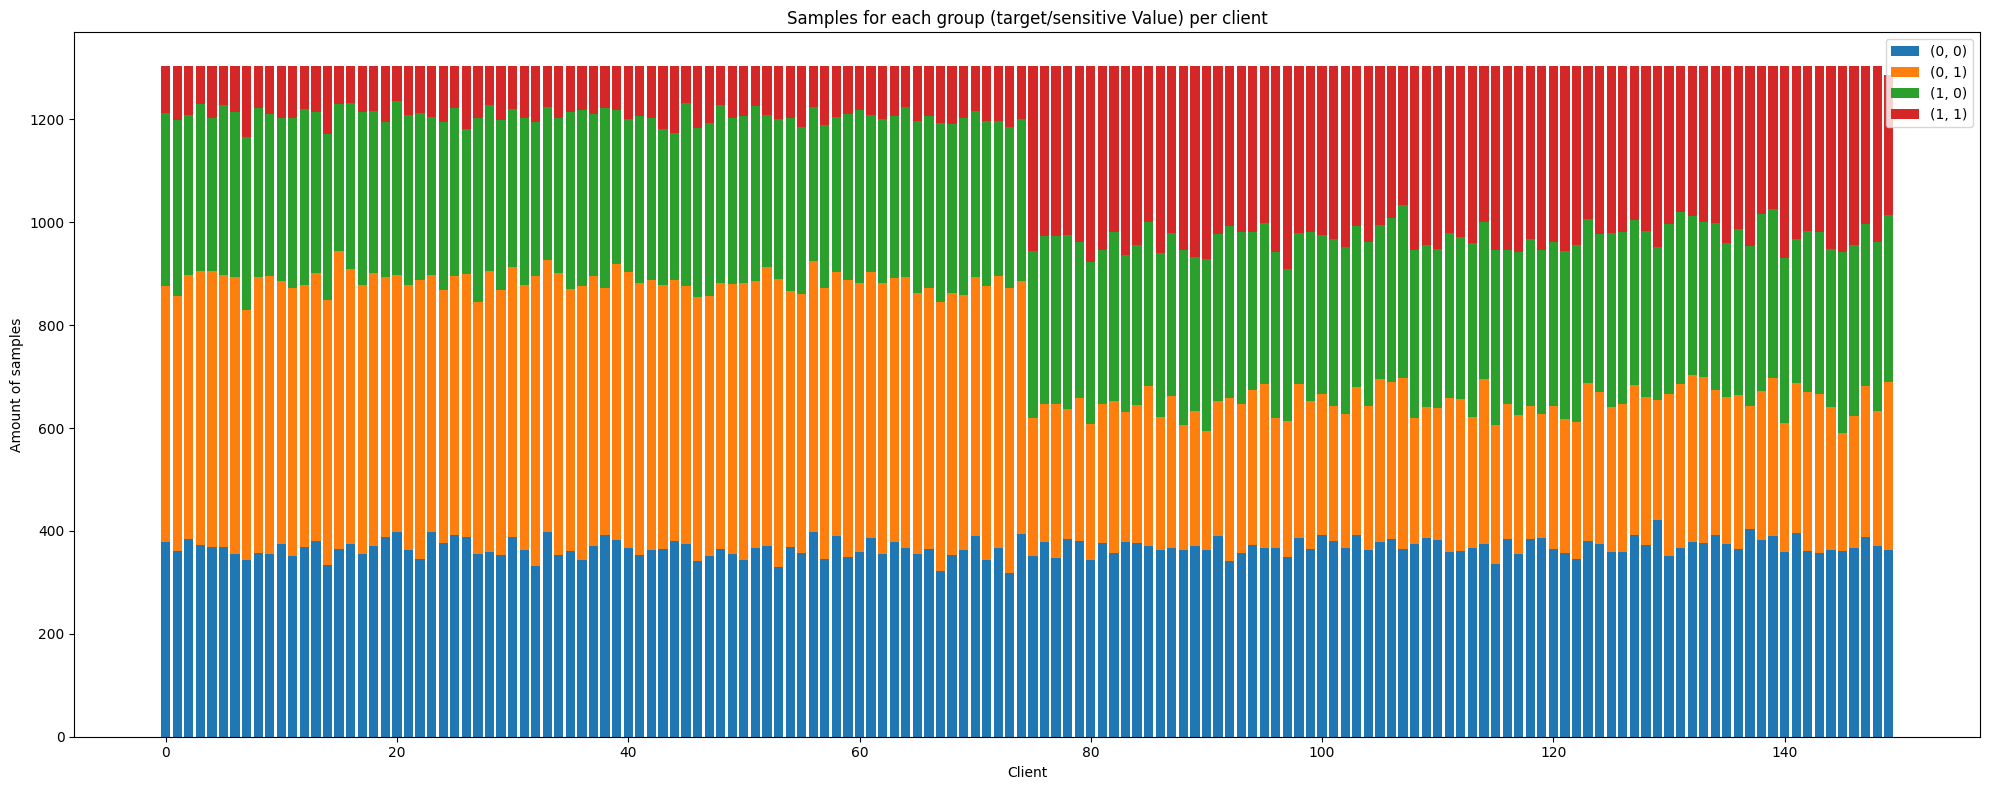

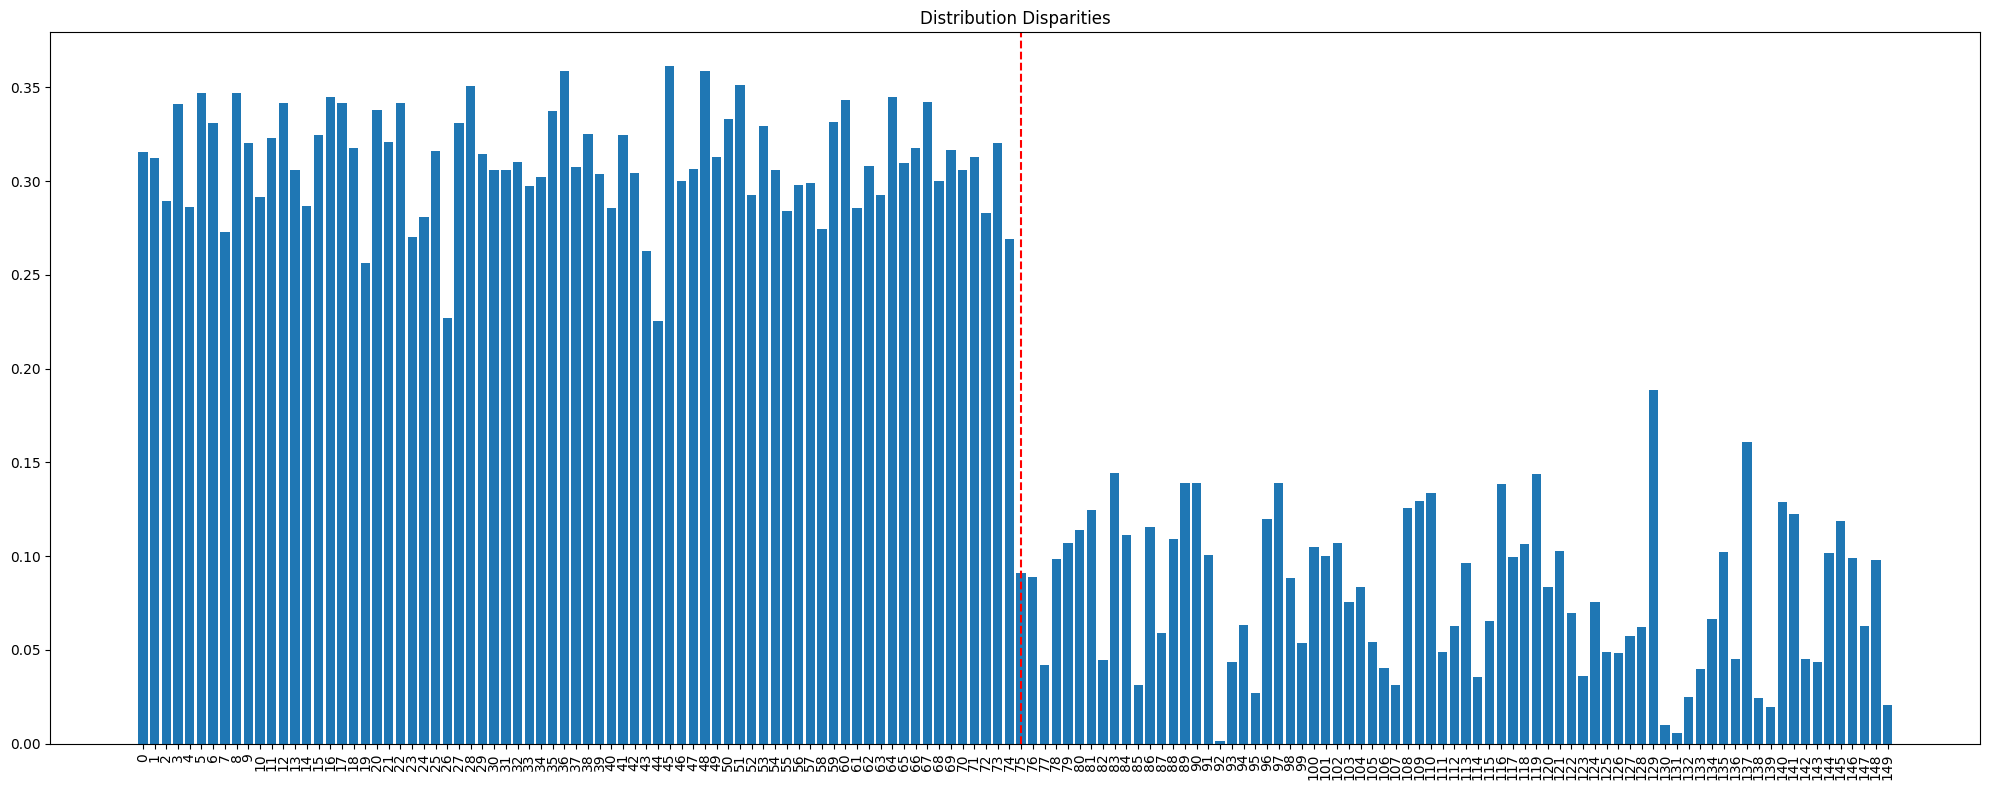

In [119]:
plot_distr(Y_0, Z_0)
plot_disparities(Y_0, Z_0)

[203, 164, 188, 157, 190, 173, 164, 163, 182, 167, 211, 174, 194, 182, 184, 206, 189, 199, 192, 180, 176, 172, 174, 183, 196, 177, 190, 188, 177, 158, 179, 180, 193, 177, 197, 189, 178, 202, 181, 176, 174, 170, 185, 187, 180, 191, 169, 191, 183, 186, 187, 187, 164, 177, 199, 179, 169, 183, 171, 198, 176, 157, 153, 176, 183, 188, 200, 189, 159, 181, 175, 184, 185, 196, 187, 193, 178, 187, 181, 203, 206, 176, 179, 181, 187, 200, 189, 176, 197, 161, 195, 182, 182, 179, 190, 195, 180, 203, 184, 183, 174, 166, 190, 199, 180, 200, 171, 180, 195, 208, 188, 203, 184, 177, 181, 192, 173, 201, 182, 187, 190, 177, 184, 180, 202, 183, 187, 189, 199, 174, 169, 191, 191, 189, 185, 174, 182, 172, 178, 174, 209, 200, 171, 180, 190, 194, 193, 154, 202, 179]
[194, 233, 214, 215, 223, 230, 231, 229, 219, 221, 201, 201, 228, 204, 242, 227, 227, 206, 198, 235, 224, 220, 219, 236, 215, 232, 222, 199, 218, 215, 205, 230, 219, 226, 202, 219, 227, 215, 221, 212, 231, 220, 226, 222, 221, 211, 234, 216, 223, 229

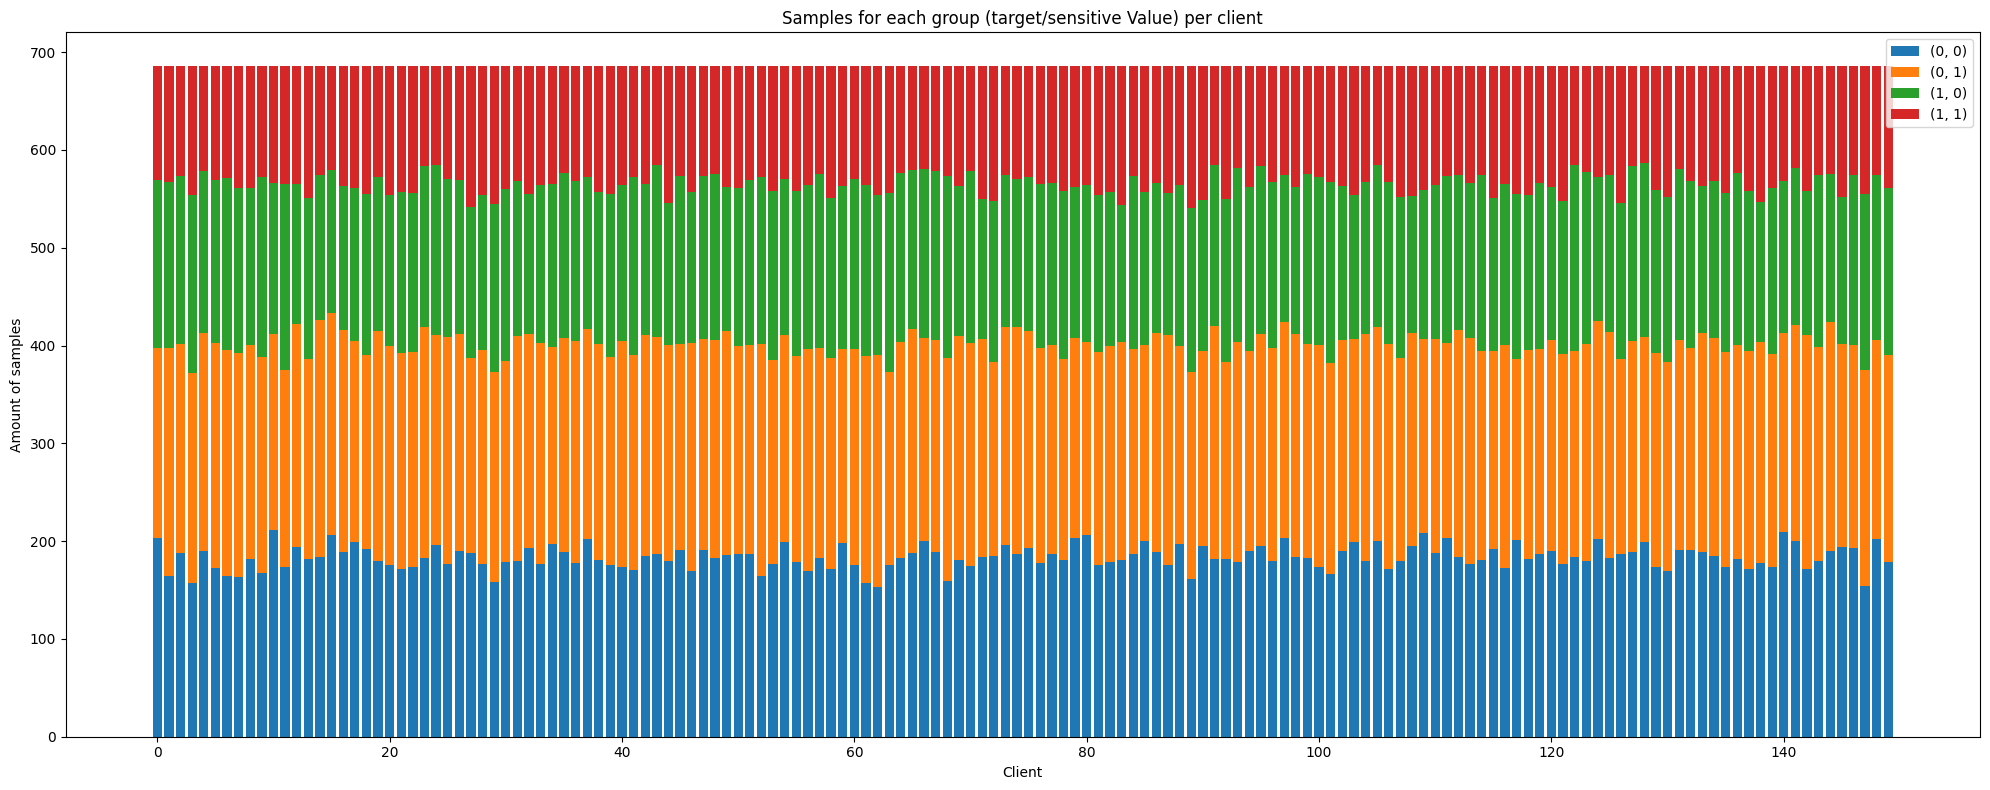

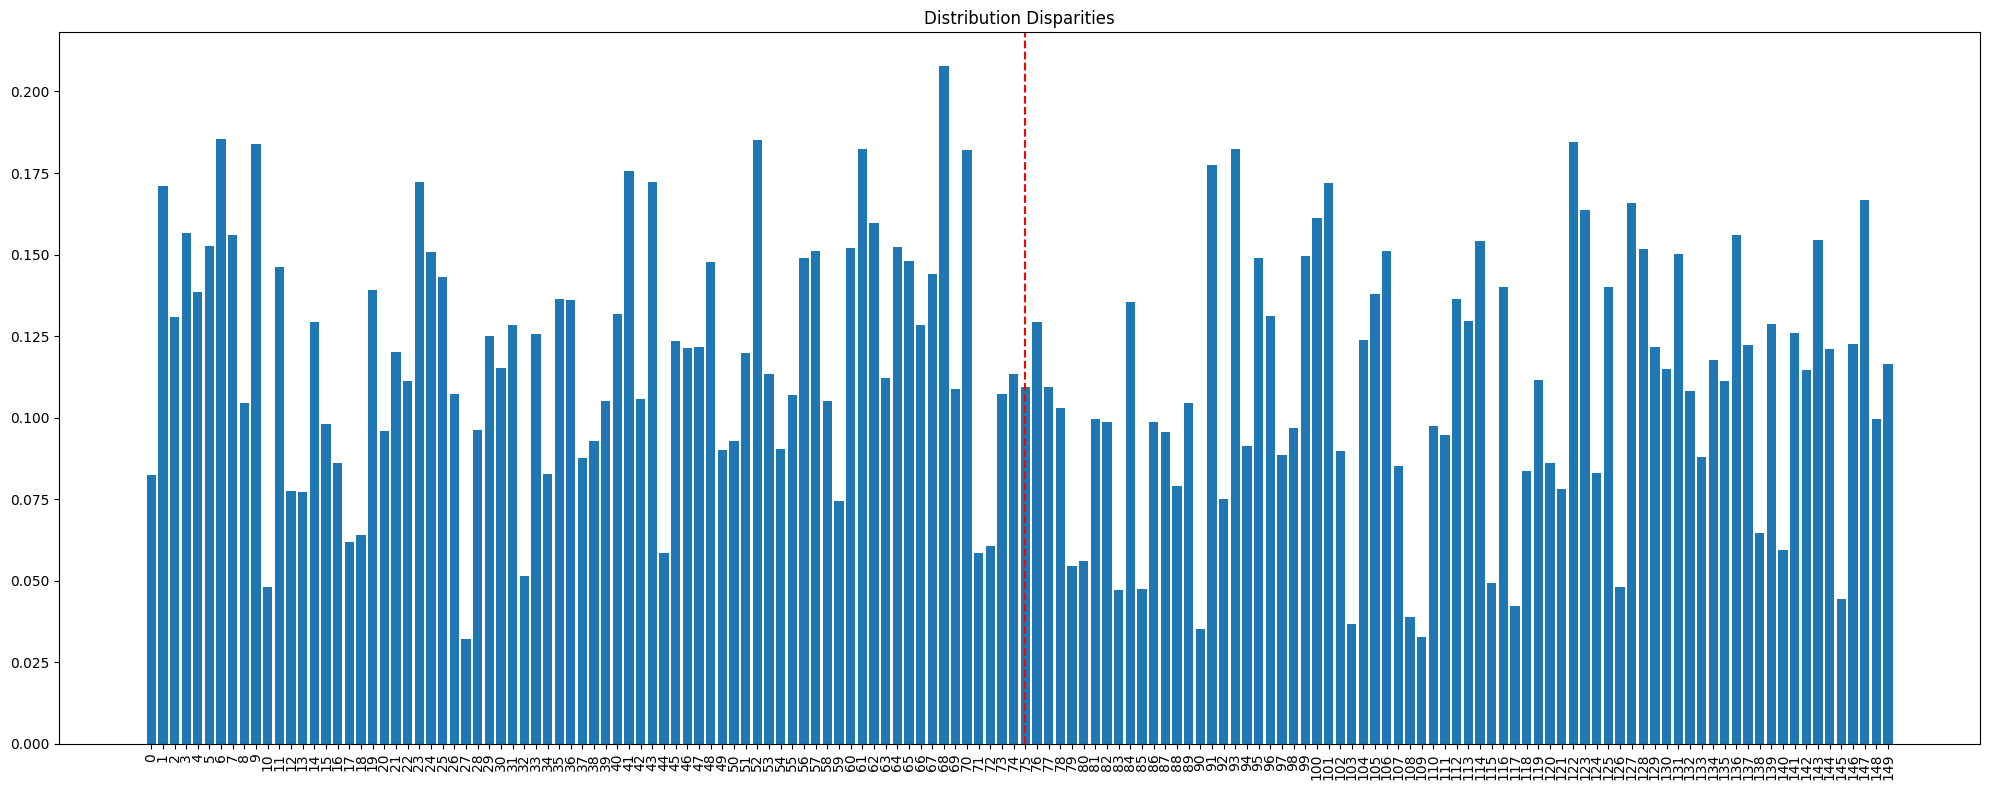

In [120]:
plot_distr(Y_1, Z_1)
plot_disparities(Y_1, Z_1)

[247, 261, 264, 247, 258, 260, 272, 281, 250, 282, 273, 273, 261, 256, 277, 266, 254, 280, 281, 290, 267, 274, 264, 261, 270, 251, 281, 269, 266, 272, 284, 250, 263, 274, 274, 269, 270, 266, 258, 270, 258, 284, 258, 288, 262, 276, 268, 284, 270, 271, 270, 254, 264, 281, 270, 261, 264, 266, 275, 269, 263, 272, 253, 293, 264, 262, 278, 267, 269, 274, 248, 284, 245, 265, 259, 276, 256, 280, 281, 261, 267, 285, 276, 274, 264, 275, 258, 294, 278, 287, 259, 285, 258, 262, 281, 264, 293, 259, 303, 244, 252, 274, 292, 292, 264, 289, 306, 257, 278, 286, 285, 273, 258, 266, 265, 262, 253, 276, 272, 250, 271, 254, 293, 268, 274, 266, 263, 301, 287, 278, 265, 269, 285, 296, 273, 281, 271, 303, 261, 263, 262, 265, 285, 270, 271, 275, 273, 292, 294, 275]
[463, 467, 473, 505, 479, 468, 476, 465, 465, 459, 472, 466, 477, 482, 457, 482, 493, 443, 478, 466, 441, 489, 451, 480, 473, 476, 473, 467, 472, 469, 464, 491, 462, 454, 453, 492, 465, 474, 488, 478, 474, 472, 459, 468, 467, 491, 468, 475, 442, 449

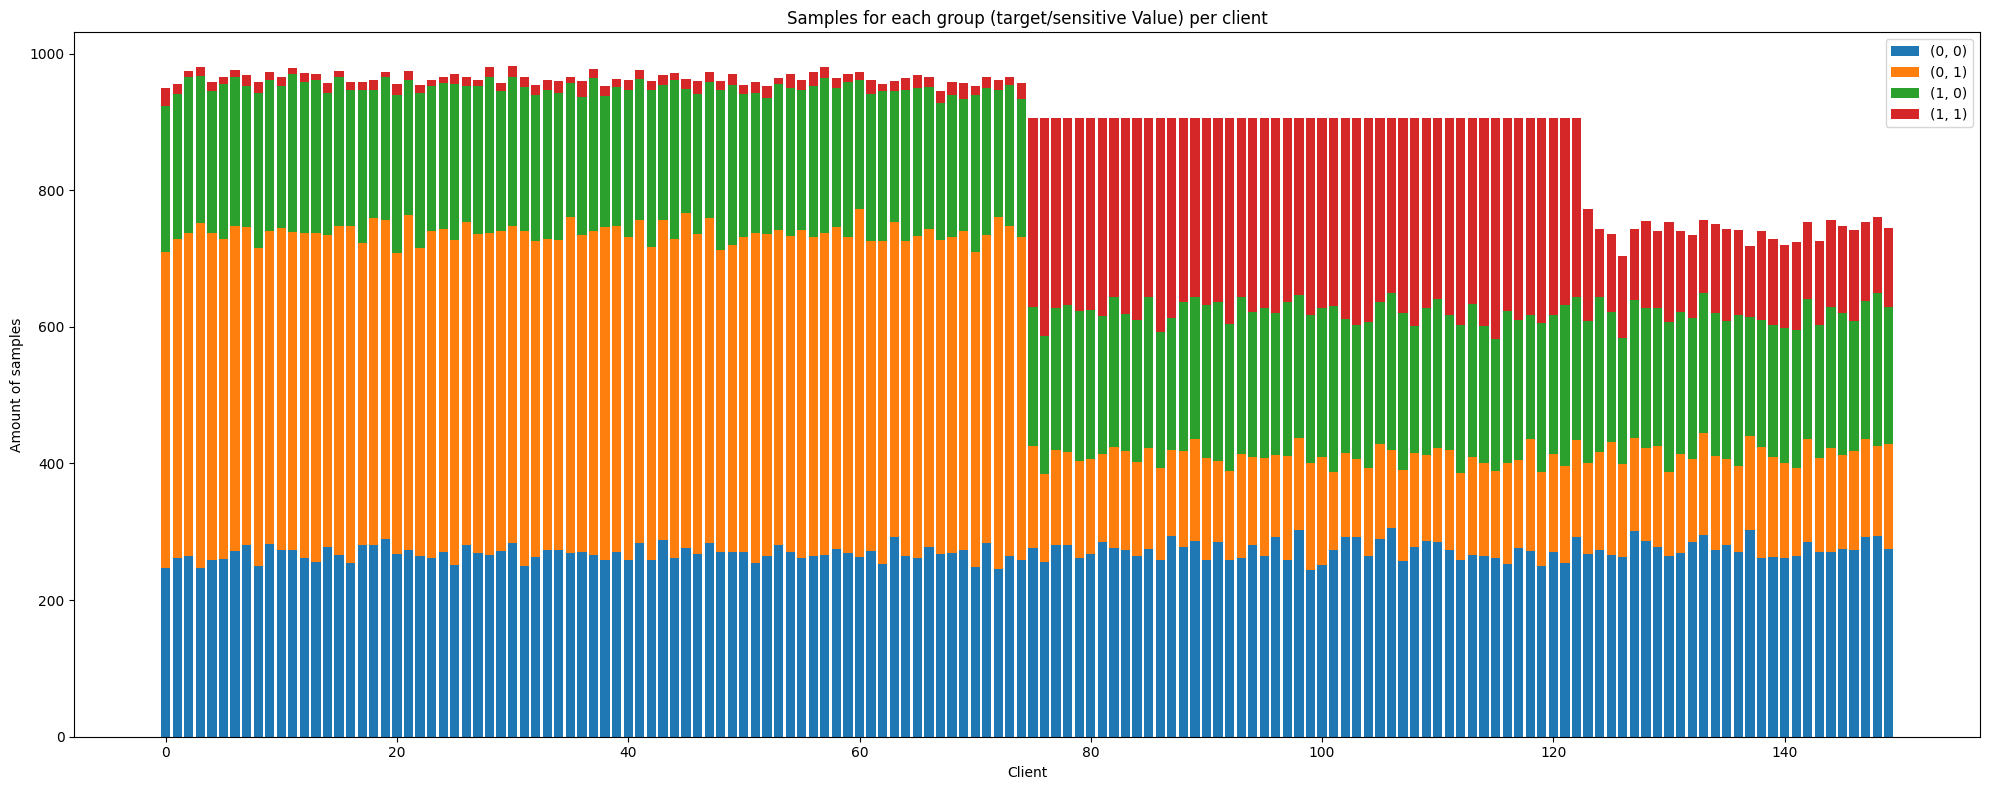

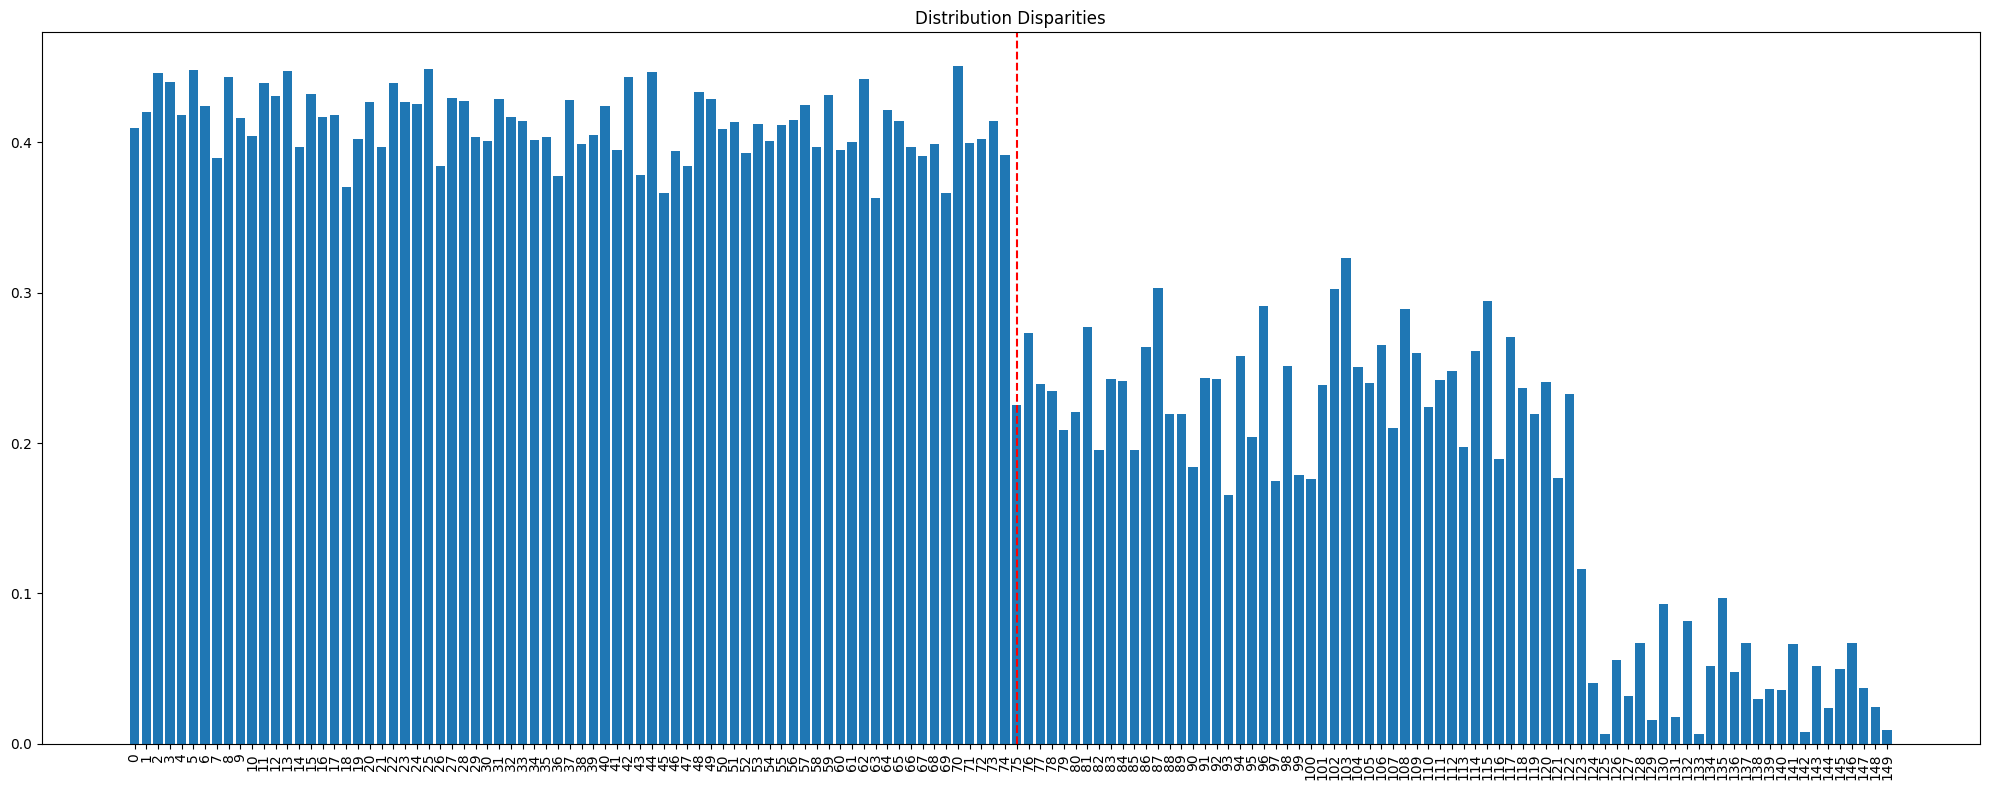

In [121]:
plot_distr(Y_2, Z_2)
plot_disparities(Y_2, Z_2)

In [130]:
import os

for node_id in range(0, 150):
    if not os.path.isdir(f"../data/continual_income_1/"):
        os.mkdir(f"../data/continual_income_1/")
    if not os.path.isdir(f"../data/continual_income_1/federated"):
        os.mkdir(f"../data/continual_income_1/federated")
    if not os.path.isdir(f"../data/continual_income_1/federated/{node_id}"):
        # create folder
        os.mkdir(f"../data/continual_income_1/federated/{node_id}")
    np.save(
        f"../data/continual_income_1/federated/{node_id}/income_dataframes_{0}.npy",
        X_0[node_id],
    )
    np.save(
        f"../data/continual_income_1/federated/{node_id}/income_dataframes_{1}.npy",
        X_2[node_id],
    )

    np.save(
        f"../data/continual_income_1/federated/{node_id}/income_labels_{0}.npy",
        Y_0[node_id],
    )
    np.save(
        f"../data/continual_income_1/federated/{node_id}/income_labels_{1}.npy",
        Y_2[node_id],
    )

    np.save(
        f"../data/continual_income_1/federated/{node_id}/income_groups_{0}.npy",
        Z_0[node_id],
    )
    np.save(
        f"../data/continual_income_1/federated/{node_id}/income_groups_{1}.npy",
        Z_2[node_id],
    )


for node_id in range(0, 150):
    with open(f"../data/continual_income_1/federated/{node_id}/metadata.json", "w") as outfile:
        json_object = json.dumps(json_file, indent=4)
        outfile.write(json_object)

In [131]:
import os

for node_id in range(0, 150):
    if not os.path.isdir(f"../data/continual_income_2/"):
        os.mkdir(f"../data/continual_income_2/")
    if not os.path.isdir(f"../data/continual_income_2/federated"):
        os.mkdir(f"../data/continual_income_2/federated")
    if not os.path.isdir(f"../data/continual_income_2/federated/{node_id}"):
        # create folder
        os.mkdir(f"../data/continual_income_2/federated/{node_id}")
    np.save(
        f"../data/continual_income_2/federated/{node_id}/income_dataframes_{0}.npy",
        X_2[node_id],
    )
    np.save(
        f"../data/continual_income_2/federated/{node_id}/income_dataframes_{1}.npy",
        X_1[node_id],
    )

    np.save(
        f"../data/continual_income_2/federated/{node_id}/income_labels_{0}.npy",
        Y_2[node_id],
    )
    np.save(
        f"../data/continual_income_2/federated/{node_id}/income_labels_{1}.npy",
        Y_1[node_id],
    )

    np.save(
        f"../data/continual_income_2/federated/{node_id}/income_groups_{0}.npy",
        Z_2[node_id],
    )
    np.save(
        f"../data/continual_income_2/federated/{node_id}/income_groups_{1}.npy",
        Z_1[node_id],
    )

for node_id in range(0, 150):
    with open(f"../data/continual_income_2/federated/{node_id}/metadata.json", "w") as outfile:
        json_object = json.dumps(json_file, indent=4)
        outfile.write(json_object)

In [132]:
import os

for node_id in range(0, 150):
    if not os.path.isdir(f"../data/continual_income_3/"):
        os.mkdir(f"../data/continual_income_3/")
    if not os.path.isdir(f"../data/continual_income_3/federated"):
        os.mkdir(f"../data/continual_income_3/federated")
    if not os.path.isdir(f"../data/continual_income_3/federated/{node_id}"):
        # create folder
        os.mkdir(f"../data/continual_income_3/federated/{node_id}")
    np.save(
        f"../data/continual_income_3/federated/{node_id}/income_dataframes_{0}.npy",
        X_1[node_id],
    )
    np.save(
        f"../data/continual_income_3/federated/{node_id}/income_dataframes_{1}.npy",
        X_2[node_id],
    )

    np.save(
        f"../data/continual_income_3/federated/{node_id}/income_labels_{0}.npy",
        Y_1[node_id],
    )
    np.save(
        f"../data/continual_income_3/federated/{node_id}/income_labels_{1}.npy",
        Y_2[node_id],
    )

    np.save(
        f"../data/continual_income_3/federated/{node_id}/income_groups_{0}.npy",
        Z_1[node_id],
    )
    np.save(
        f"../data/continual_income_3/federated/{node_id}/income_groups_{1}.npy",
        Z_2[node_id],
    )

for node_id in range(0, 150):
    with open(f"../data/continual_income_3/federated/{node_id}/metadata.json", "w") as outfile:
        json_object = json.dumps(json_file, indent=4)
        outfile.write(json_object)